#Day 29 - Pengantar Klasifikasi : Logistic Regression

Saat ini kita akan memperlajari **modul Klasifikasi**!

Jika regresi memprediksi *angka* (mis. harga), maka **klasifikasi** memprediksi *kategori/label* (mis. "diabetes" atau "tidak").

Notebook ini memperkenalkan algoritma klasifikasi paling fundamental:
**Logistic Regression**.

> 🎯 **Tujuan Pembelajaran**
> - Memahami perbedaan **regresi vs klasifikasi**.
> - Menangani **nilai 0 yang tidak masuk akal** sebagai missing → imputasi.
> - Menerapkan **scaling** sebelum melatih Logistic Regression.
> - Mengevaluasi dengan **akurasi**, **confusion matrix**, dan **classification_report**.

## Tentang Dataset

**Pima Indians Diabetes Dataset** berisi data medis pasien wanita beserta status
diabetesnya. Target: **`Outcome`** (1 = diabetes, 0 = tidak).

- **Sumber:** [Kaggle — akshaydattatraykhare/diabetes-dataset](https://www.kaggle.com/datasets/akshaydattatraykhare/diabetes-dataset)
- **Jumlah data:** 768 baris × 9 kolom

| Kolom | Arti |
|-------|------|
| `Pregnancies` | Jumlah kehamilan |
| `Glucose` | Kadar glukosa darah |
| `BloodPressure` | Tekanan darah |
| `SkinThickness` | Ketebalan lipatan kulit |
| `Insulin` | Kadar insulin |
| `BMI` | Indeks massa tubuh |
| `DiabetesPedigreeFunction` | Skor riwayat keluarga |
| `Age` | Usia |
| `Outcome` | **(Target)** 1 = diabetes, 0 = tidak |

## Import Library

- **pandas / numpy** → olah data.
- **matplotlib / seaborn** → visualisasi & confusion matrix.
- **scikit-learn** → `LogisticRegression`, `StandardScaler`, `train_test_split`,
  serta metrik klasifikasi (`accuracy_score`, `confusion_matrix`, `classification_report`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

## Import Dataset

In [7]:
# Download dataset directly from a public URL to bypass Kaggle API authentication
!wget -q https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv -O diabetes.csv

import pandas as pd
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Eksplorasi Awal Dataset

In [9]:
# Menampilkan informasi umum dataset (tipe data, non-null count, dimensi)
print("=== Informasi Dataset ===")
df.info()

# Menampilkan statistik deskriptif dataset
print("\n=== Statistik Deskriptif ===")
df.describe()

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

=== Statistik Deskriptif ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Cleaning Data

### Mengatasi Nilai 0 yang Tidak Masuk Akal (Missing Values)

Kita akan mengubah nilai `0` pada kolom `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, dan `BMI` menjadi `NaN`. Setelah itu, kita akan menghitung jumlah missing values di setiap kolom.

In [11]:
# Daftar kolom yang tidak boleh bernilai 0
columns_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Ganti nilai 0 dengan NaN
df[columns_with_zero] = df[columns_with_zero].replace(0, np.nan)

# Cek jumlah missing values sekarang
print("Jumlah missing values per kolom:")
print(df.isnull().sum())

Jumlah missing values per kolom:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


### Imputasi Missing Values dengan Median

Kita menggunakan median karena median lebih robas (kebal) terhadap outlier dibandingkan nilai rata-rata (mean).

In [12]:
# Inisialisasi SimpleImputer dengan strategi median
imputer = SimpleImputer(strategy='median')

# Lakukan fit dan transform pada kolom yang memiliki missing values
df[columns_with_zero] = imputer.fit_transform(df[columns_with_zero])

# Pastikan kembali bahwa sudah tidak ada missing values
print("Jumlah missing values setelah imputasi:")
print(df.isnull().sum())

Jumlah missing values setelah imputasi:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Eksplorasi Data Analisis dan Visualisasi Dta

/tmp/ipykernel_1184/885388335.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Outcome', palette='Set2')


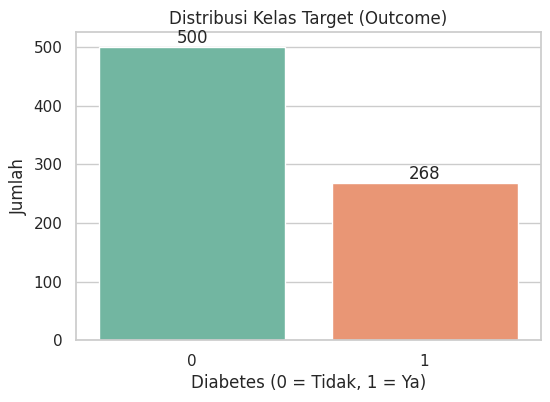

In [24]:
# Mengatur gaya visualisasi seaborn
sns.set_theme(style="whitegrid")

# 1. Visualisasi Distribusi Target (Outcome)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Outcome', palette='Set2')
plt.title('Distribusi Kelas Target (Outcome)')
plt.xlabel('Diabetes (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah')
for i in range(2):
    plt.text(i, df['Outcome'].value_counts()[i], str(df['Outcome'].value_counts()[i]), ha='center', va='bottom')
plt.show()

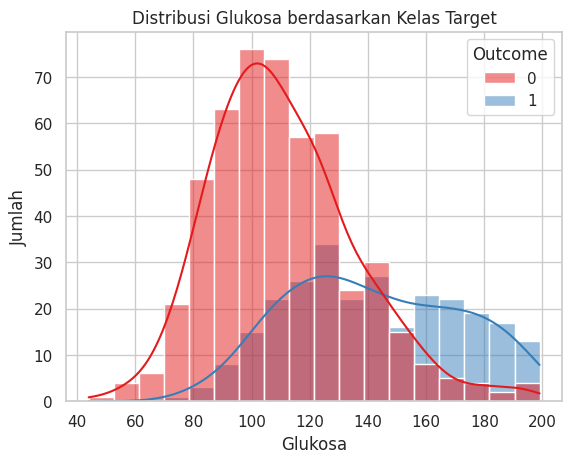

In [28]:
# 2 Distribusi Glukosa dengan Target

sns.histplot(data=df, x='Glucose', hue='Outcome', kde=True, palette='Set1')
plt.title('Distribusi Glukosa berdasarkan Kelas Target')
plt.xlabel('Glukosa')
plt.ylabel('Jumlah')
plt.show()

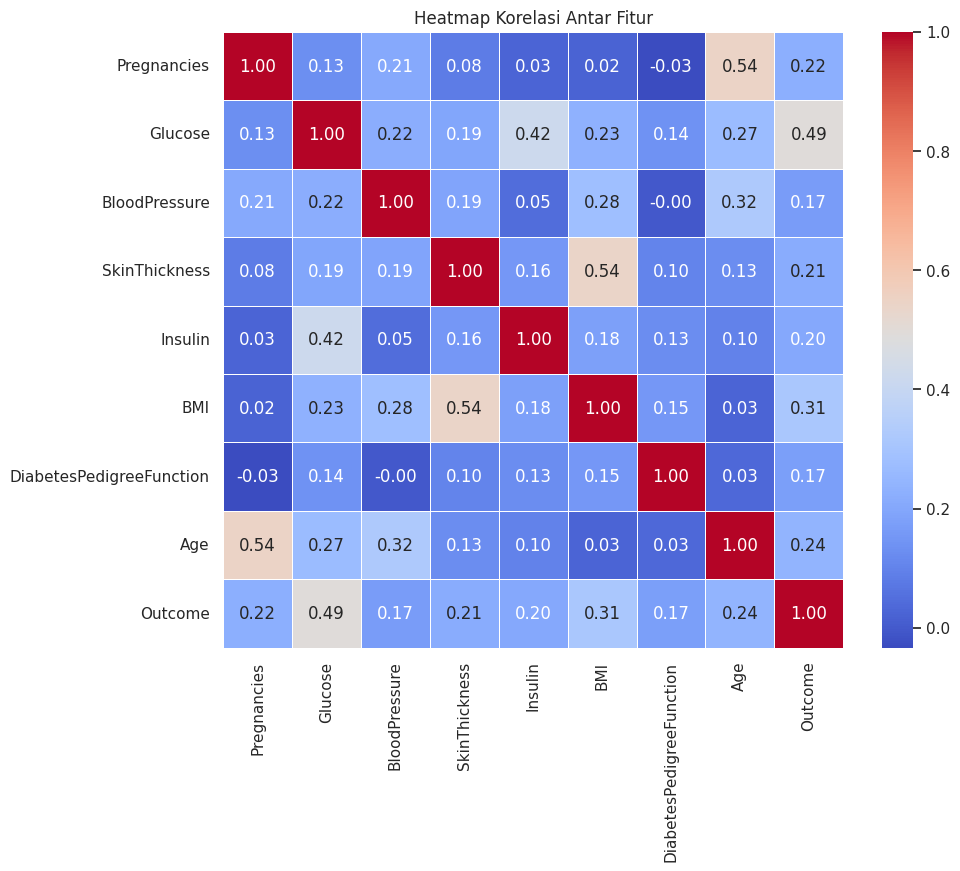

In [21]:
# 3. Visualisasi Korelasi Antar Fitur (Heatmap)
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

## Preprocessing : Spliting Data & Scaling

In [14]:
# 1. Memisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# 2. Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Feature Scaling dengan StandardScaler
scaler = StandardScaler()

# Fit dan transform pada data training, dan transform pada data testing
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dimensi data training:", X_train_scaled.shape)
print("Dimensi data testing:", X_test_scaled.shape)

Dimensi data training: (614, 8)
Dimensi data testing: (154, 8)


## Modeling : Logistic Regression

In [15]:
# 1. Inisialisasi model Logistic Regression
model = LogisticRegression(random_state=42)

# 2. Melatih model dengan data training yang sudah di-scale
model.fit(X_train_scaled, y_train)

# 3. Melakukan prediksi pada data testing yang sudah di-scale
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Model Logistic Regression berhasil dilatih dan diuji!")

Model Logistic Regression berhasil dilatih dan diuji!


## Evaluation

### Akurasi : Bandingkan dengan Baseline

In [16]:
# 1. Menghitung Akurasi Model
accuracy = accuracy_score(y_test, y_pred)

# 2. Menghitung Baseline Accuracy (jika kita selalu memprediksi kelas mayoritas yaitu 0)
baseline_accuracy = (y_test == 0).mean()

print(f"Akurasi Model Logistic Regression: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Baseline Accuracy (Selalu Tebak 0) : {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")

Akurasi Model Logistic Regression: 0.7078 (70.78%)
Baseline Accuracy (Selalu Tebak 0) : 0.6494 (64.94%)


### Confusion Matrix & Classification Report

Selanjutnya, mari kita visualisasikan Confusion Matrix dan mencetak Classification Report lengkap.

=== Classification Report ===
                    precision    recall  f1-score   support

Tidak Diabetes (0)       0.75      0.82      0.78       100
      Diabetes (1)       0.60      0.50      0.55        54

          accuracy                           0.71       154
         macro avg       0.68      0.66      0.67       154
      weighted avg       0.70      0.71      0.70       154



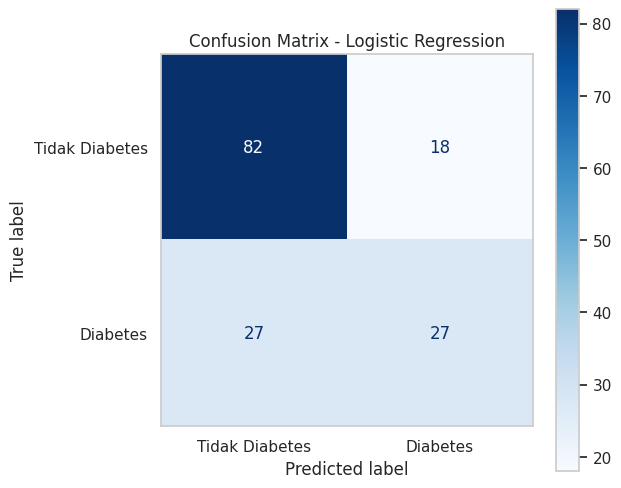

In [18]:
# 1. Menampilkan Classification Report (Tanda kurung penutup sudah diperbaiki)
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Tidak Diabetes (0)', 'Diabetes (1)']))

# 2. Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Diabetes', 'Diabetes'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Logistic Regression')
plt.grid(False)
plt.show()

Interpretasi:

- Akurasi Keseluruhan (0.71 atau 71%):
  - Secara keseluruhan, model berhasil menebak status (diabetes atau tidak) dengan benar sebesar 71% dari total 154 data uji.

- Kelas "Tidak Diabetes" (0):

  - Model bekerja cukup baik dalam mendeteksi orang yang tidak diabetes, dengan tingkat ketepatan (precision) 75% dan kemampuan mengenali pasien sehat (recall) sebesar 82%.

- Kelas "Diabetes" (1):

  - Performa model untuk kelas ini lebih rendah.
  - Dari semua orang yang didiagnosis diabetes oleh model, hanya 60% yang benar (precision).
  - Selain itu, model hanya mampu mendeteksi 50% dari total penderita diabetes yang sebenarnya ada di data uji (recall), yang berarti ada separuh pasien diabetes yang terlewat atau tidak terdeteksi oleh model.

Kesimpulan:


  - Model ini sudah lumayan andal dalam mengenali orang yang tidak diabetes, tetapi masih lemah dalam mendeteksi pasien yang benar-benar positif diabetes, sehingga perlu ada peningkatan atau penyesuaian (karena kemungkinan besar data pasien diabetes lebih sedikit dibandingkan yang tidak diabetes).

### Feature Importance

/tmp/ipykernel_1184/3515233239.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Koefisien', y='Fitur', palette='mako')


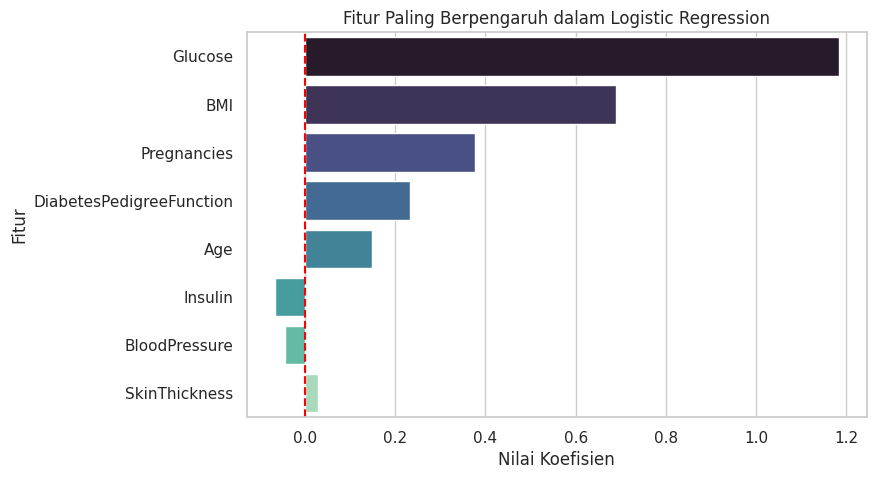

                      Fitur  Koefisien
1                   Glucose   1.182511
5                       BMI   0.688735
0               Pregnancies   0.377502
6  DiabetesPedigreeFunction   0.233386
7                       Age   0.147798
4                   Insulin  -0.066157
2             BloodPressure  -0.044066
3             SkinThickness   0.028225


In [19]:
# Mendapatkan koefisien dari model
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_[0]
})

# Mengurutkan fitur berdasarkan nilai absolut koefisien terbesar
coef_df['Abs_Koefisien'] = coef_df['Koefisien'].abs()
coef_df = coef_df.sort_values(by='Abs_Koefisien', ascending=False).drop(columns=['Abs_Koefisien'])

# Visualisasi Koefisien
plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x='Koefisien', y='Fitur', palette='mako')
plt.title('Fitur Paling Berpengaruh dalam Logistic Regression')
plt.xlabel('Nilai Koefisien')
plt.ylabel('Fitur')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

print(coef_df)

Interpretasi:

- Faktor Paling Dominan (Pengaruh Positif Terbesar):
  - Glucose dan BMI memiliki batang paling panjang ke kanan. Ini berarti kadar glukosa dan indeks massa tubuh (BMI) adalah dua faktor utama yang paling kuat meningkatkan risiko seseorang terkena diabetes menurut model.   

- Faktor Pendukung Lainnya:
  - Pregnancies, DiabetesPedigreeFunction, dan Age juga memberikan pengaruh positif (ke kanan), yang berarti semakin tinggi nilai-nilai tersebut, semakin besar pula peluang terdeteksi diabetes.   
  
- Faktor dengan Pengaruh Negatif Kecil:
  - Insulin, BloodPressure, and SkinThickness berada di sekitar garis nol atau sedikit ke kiri, yang menunjukkan pengaruhnya terhadap prediksi model relatif kecil atau berlawanan arah dibanding glukosa.   

## Kesimpulan dan Insight

### 🎯 Kesimpulan Utama & Insight

1. **Fitur Paling Berpengaruh**:
   - **`Glucose`** dan **`BMI`** adalah dua prediktor terkuat dengan koefisien positif yang tinggi. Hal ini berarti semakin tinggi kadar glukosa atau nilai BMI seseorang, peluangnya terkena diabetes akan semakin meningkat secara signifikan.

2. **Pentingnya Data Preprocessing**:
   - Mengganti nilai `0` yang tidak realistis menjadi `NaN` dan mengimputasinya dengan **median** membantu model kita belajar dari representasi data klinis yang lebih akurat.
   - **Feature Scaling** (`StandardScaler`) sangat krusial bagi Logistic Regression agar semua fitur dengan rentang nilai yang berbeda (misal: `Insulin` hingga ratusan vs `DiabetesPedigreeFunction` di bawah 2) memberikan kontribusi yang adil saat proses training.

3. **Analisis Metrik Evaluasi**:
   - Akurasi model kita mencapai **70.78%**, mengungguli baseline akurasi tebakan mayoritas sebesar **64.94%**.
   - Namun, nilai **Recall** untuk pasien diabetes masih bernilai **50%**. Dalam bidang medis, recall yang rendah cukup berisiko karena berarti ada sekitar 50% penderita diabetes aktual yang salah diprediksi sebagai sehat (*False Negative*). Langkah peningkatan ke depannya dapat melibatkan penanganan ketidakseimbangan kelas (*imbalance data*) atau penggunaan algoritma klasifikasi non-linear lainnya.